In [3]:
import warnings
warnings.filterwarnings("ignore", message=r"Passing", category=FutureWarning)
import sys
import matplotlib.pyplot as plt
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Amy_2P/Analysis/correlation'])
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')

#from save_corr_matrices import save_corrmat_plots,save_corr_mat
import seaborn as sb
import matplotlib.pyplot as plt
import pickle
import textwrap
from matplotlib import rcParams
import numpy as np

In [4]:
ani='989N'
fov='FOV2'

In [7]:
file = '/Volumes/AM_SSD1/Spont2P/Analysis/correlation/corr_mats/989N_FOV2bin50_corr_.pkl'
with open(file,'rb') as f:
    data =pickle.load(f)
Cpre=data['Cpre']
Cpost=data['Cpost']
split=data['n_tag']


In [8]:
EE_pre = Cpre.corr[:split,:split]
EE_post = Cpost.corr[:split,:split]

EN_pre = Cpre.corr[split:,:split]
EN_post = Cpost.corr[split:,:split]

NN_pre =  Cpre.corr[split:,split:]
NN_post =  Cpost.corr[split:,split:]


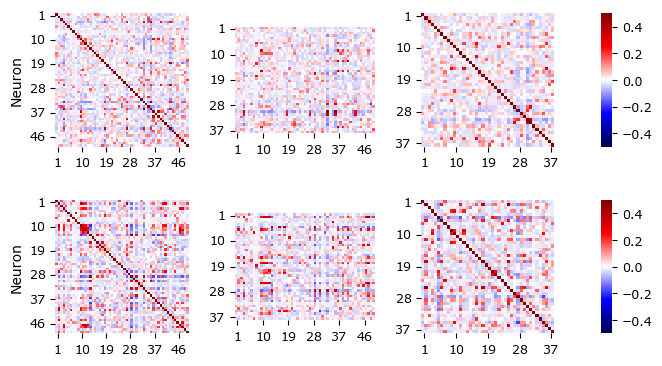

In [9]:
vmin=-.5
vmax=.5
N=EE_pre.shape[0]
step=10
fig,ax=plt.subplots(2,4,figsize=(7,4),gridspec_kw={'width_ratios':[1,1,1,.08]})
sb.heatmap(data=EE_pre,vmin=vmin,vmax=vmax,cmap='seismic',center=0,ax=ax[0,0],square=True,cbar=False)
sb.heatmap(data=EE_post,vmin=vmin,vmax=vmax,cmap='seismic',center=0,ax=ax[1,0],square=True,cbar_ax=ax[0,3])

sb.heatmap(data=EN_pre,vmin=vmin,vmax=vmax,cmap='seismic',center=0,ax=ax[0,1],square=True,cbar=False)
sb.heatmap(data=EN_post,vmin=vmin,vmax=vmax,cmap='seismic',center=0,ax=ax[1,1],square=True,cbar=False)

sb.heatmap(data=NN_pre,vmin=vmin,vmax=vmax,cmap='seismic',center=0,ax=ax[0,2],square=True,cbar=False)
sb.heatmap(data=NN_post,vmin=vmin,vmax=vmax,cmap='seismic',center=0,ax=ax[1,2],square=True,cbar_ax=ax[1,3])

for i in [0,1,2,4,5,6]:
    if i==0 or i==4:
        Ny=EE_pre.shape[0]
        Nx=EE_pre.shape[1]
    if i==1 or i==5:
        Ny=EN_pre.shape[0]
        Nx=EN_pre.shape[1]
    if i==2 or i==6:
        Ny=NN_pre.shape[0]
        Nx=NN_pre.shape[1]

    axis=ax.flatten()[i]
    plt.setp(axis,xticks=np.arange(1,Nx+1,step),xticklabels = np.round(np.arange(1,Nx,step-1)),
         yticks=np.arange(1,Ny+1,step),yticklabels = np.round(np.arange(1,Ny,step-1)))
    plt.sca(axis)
    plt.xticks(rotation = 0)
    plt.yticks(rotation = 0)
ax[0,0].set_ylabel('Neuron')    
ax[1,0].set_ylabel('Neuron')    

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4,hspace=0.4)
plt.savefig('/Users/amonast/Dropbox (BOSTON UNIVERSITY)/Manuscripts/Engram2P/Figures/RevisionFigures/Figure4_Supp5/Fig4A_989NFOV2_6_rvals.svg',transparent=True)

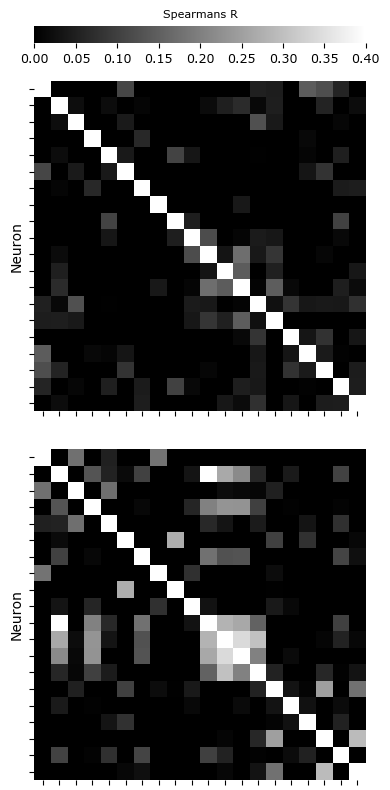

In [ ]:
vmin=0
vmax = .4
step = 10

fig, ax = plt.subplots(3, 1, figsize=(4, 8),
                       gridspec_kw={'height_ratios': [0.05, 1, 1]})

sb.heatmap(data=EE_pre[:20,:20], vmin=vmin, vmax=vmax, cmap='binary_r', 
           ax=ax[1], cbar=False)
sb.heatmap(data=EE_post[:20,:20], vmin=vmin, vmax=vmax, cmap='binary_r', 
           ax=ax[2], cbar_ax=ax[0],cbar_kws={'orientation': 'horizontal'})


Ny, Nx = EE_pre[:20,:20].shape
#     # plt.setp(axis, xticks=np.arange(1, Nx+1, step), xticklabels=np.round(np.arange(1, Nx, step-1)),
#     #          yticks=np.arange(1, Ny+1, step), yticklabels=np.round(np.arange(1, Ny, step-1)))
#     ticks = np.arange(0, Nx, step)
#     axis.set_xticks(ticks + 0.5)
#     axis.set_xticklabels((ticks + 1).astype(int), rotation=0)
#     axis.set_yticks(ticks + 0.5)
#     axis.set_yticklabels((ticks + 1).astype(int), rotation=0)
#     plt.sca(axis)
#     plt.xticks(rotation=0)
#     plt.yticks(rotation=0)
for axis in [ax[1], ax[2]]:
    axis.tick_params(labelbottom=False, labelleft=False) 


ax[0].set_title('Spearmans R',rotation='horizontal',size=8)
ax[1].set_ylabel('Neuron')
ax[2].set_ylabel('Neuron')

#plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig('Fig4C_matrices.svg', transparent=True)

In [10]:
Cpre.pvals.shape

(97, 97)

# PVALS 

In [11]:
EE_pre = Cpre.pvals[:split,:split]
EE_post = Cpost.pvals[:split,:split]

EN_pre = Cpre.pvals[split:,:split]
EN_post = Cpost.pvals[split:,:split]

NN_pre =  Cpre.pvals[split:,split:]
NN_post =  Cpost.pvals[split:,split:]


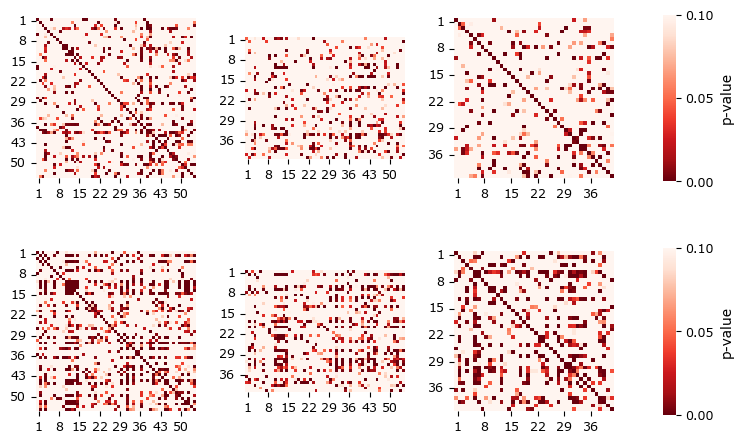

In [ ]:
vmin=0
vmax=.05
center=.005
cmap='RdGy'
N=EE_pre.shape[0]
step=7

import matplotlib.colors as mcolors

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=0.1)
cmap = 'Reds_r'

# then 

fig,ax=plt.subplots(2,4,figsize=(8,5),gridspec_kw={'width_ratios':[1,1,1,.08]})
sb.heatmap(data=EE_pre,cmap=cmap,norm=norm,ax=ax[0,0],square=True,cbar=False)
sb.heatmap(data=EE_post,cmap=cmap,norm=norm,ax=ax[1,0],square=True,cbar_ax=ax[0,3],
           cbar_kws={'ticks': [0, 0.05, 0.1], 'label': 'p-value'})

sb.heatmap(data=EN_pre,cmap=cmap,norm=norm,ax=ax[0,1],square=True,cbar=False)
sb.heatmap(data=EN_post,cmap=cmap,norm=norm,ax=ax[1,1],square=True,cbar=False)

sb.heatmap(data=NN_pre,cmap=cmap,norm=norm,ax=ax[0,2],square=True,cbar=False)
sb.heatmap(data=NN_post,cmap=cmap,norm=norm,ax=ax[1,2],square=True,cbar_ax=ax[1,3],
               cbar_kws={'ticks': [0, 0.05, 0.1], 'label': 'p-value'}
)

for i in [0,1,2,4,5,6]:
    if i==0 or i==4:
        Ny=EE_pre.shape[0]
        Nx=EE_pre.shape[1]
    if i==1 or i==5:
        Ny=EN_pre.shape[0]
        Nx=EN_pre.shape[1]
    if i==2 or i==6:
        Ny=NN_pre.shape[0]
        Nx=NN_pre.shape[1]

    axis=ax.flatten()[i]
    plt.setp(axis,xticks=np.arange(1,Nx+1,step),xticklabels = np.round(np.arange(1,Nx,step)),
         yticks=np.arange(1,Ny+1,step),yticklabels = np.round(np.arange(1,Ny,step)))
    plt.sca(axis)
    plt.xticks(rotation = 0)
    plt.yticks(rotation = 0)
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4,hspace=0.4)
plt.savefig('SuppFig5A_989NFOV2_6_pvals.svg',transparent=True)

In [11]:
rvals = Cpre.corr[:split,:split]
pvals = Cpre.pvals[:split,:split]

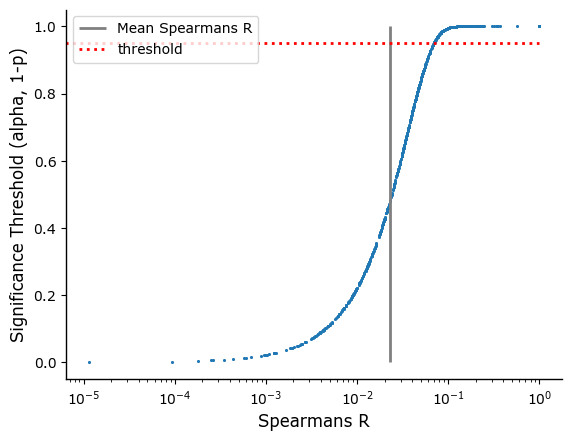

In [14]:
plt.scatter(rvals,1-pvals,s=1)
plt.vlines(np.mean(rvals),0,1,color='gray',label='Mean Spearmans R')
plt.hlines([.95],0,1,color='red',label='threshold',linestyle='dotted')

plt.gca().set_xscale('log')
plt.xlabel('Spearmans R')
plt.ylabel('Significance Threshold (alpha, 1-p)')
sb.despine()
plt.legend()

